In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, Dataset, random_split
import random

from IPython.display import display

Matplotlib is building the font cache; this may take a moment.


In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
torch.set_default_device(DEVICE)

Using device: cuda


In [3]:
data = pd.read_csv('ranking_dataset.csv')
data.describe()
X = data.iloc[:, 0:10]
y = data.iloc[:, 10:20]
display(X.describe())
display(y.describe())
display(X.head())
display(y.head())

,val_0,val_1,val_2,val_3,val_4,val_5,val_6,val_7,val_8,val_9
count,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,500.537200,506.623500,501.396300,501.42390,493.817300,495.837500,501.616300,505.314100,500.361700,500.02570
std,290.444477,289.410167,288.372805,289.29438,289.255414,290.777883,288.663129,288.731189,288.747163,290.38134
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,248.000000,255.750000,256.000000,251.00000,244.000000,240.000000,250.750000,257.000000,249.000000,248.00000
50%,500.000000,511.000000,500.000000,505.00000,489.000000,496.000000,504.000000,504.000000,501.500000,501.00000
75%,755.000000,757.000000,752.250000,754.25000,745.000000,746.000000,753.250000,757.000000,752.000000,754.00000
max,999.000000,999.000000,999.000000,999.00000,999.000000,999.000000,999.000000,999.000000,999.000000,999.00000


,rank_0,rank_1,rank_2,rank_3,rank_4,rank_5,rank_6,rank_7,rank_8,rank_9
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.508600,4.546900,4.49630,4.511000,4.444500,4.443100,4.506400,4.544000,4.498000,4.501200
std,2.876031,2.888639,2.86056,2.866409,2.884086,2.878297,2.857022,2.867523,2.861261,2.882365
min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,2.00000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
50%,5.000000,5.000000,4.00000,5.000000,4.000000,4.000000,5.000000,5.000000,4.000000,4.000000
75%,7.000000,7.000000,7.00000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000
max,9.000000,9.000000,9.00000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000


,val_0,val_1,val_2,val_3,val_4,val_5,val_6,val_7,val_8,val_9
0,542,67,876,414,26,335,620,924,950,113
1,378,14,210,954,231,572,315,295,567,706
2,749,876,73,111,899,213,541,769,287,219
3,372,880,475,329,733,564,739,376,632,10
4,186,822,577,519,707,123,143,294,693,677


,rank_0,rank_1,rank_2,rank_3,rank_4,rank_5,rank_6,rank_7,rank_8,rank_9
0,5,1,7,4,0,3,6,8,9,2
1,5,0,1,9,2,7,4,3,6,8
2,6,8,0,1,9,2,5,7,4,3
3,2,9,4,1,7,5,8,3,6,0
4,2,9,5,4,8,0,1,3,7,6


In [8]:
class RankingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx].unsqueeze(-1), self.y[idx]


dataset = RankingDataset(X, y)
train_dataloader, test_dataloader, valid_dataloader = [
    DataLoader(x, batch_size=32, shuffle=True, generator=torch.Generator(DEVICE))
    for x in random_split(dataset, [0.6, 0.2, 0.2], generator=torch.Generator(DEVICE))
]

In [5]:
class RNN(torch.nn.Module):
    def __init__(self):
        """Initialize a module with the following architecture:
        - RNN layer with input size 1 and hidden size 128, with 5 layers and batch_first=True
        - ReLU activation
        - Linear layer with input size 128 and output size 10
        """
        super().__init__()
        self.rnn = torch.nn.RNN(
            input_size=1, hidden_size=128, batch_first=True, num_layers=3
        )
        self.mlp = torch.nn.Sequential(
            torch.nn.Linear(128, 128), torch.nn.ReLU(), torch.nn.Linear(128, 10)
        )

    def forward(self, x):
        rnn_out, hidden = self.rnn(x)
        output = self.mlp(hidden[-1])
        return output


model = RNN().to(DEVICE)
print(model)

RNN(
  (rnn): RNN(1, 128, num_layers=3, batch_first=True)
  (mlp): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [9]:
def train(model, train_dataloader, valid_dataloader, epochs=10):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = torch.nn.MSELoss()

    losses = []
    valid_losses = []
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_dataloader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        losses.append(total_loss / len(train_dataloader))
        print(f"Epoch {epoch+1}/{epochs}, Loss: {losses[-1]:.4f}")

        model.eval()
        with torch.no_grad():
            valid_loss = 0
            for X_batch, y_batch in valid_dataloader:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                valid_loss += loss.item()
        valid_losses.append(valid_loss / len(valid_dataloader))
        print(f"Validation Loss: {valid_losses[-1]:.4f}")

    return losses, valid_losses

Epoch 1/30, Loss: 9.6246
Validation Loss: 8.2593
Epoch 2/30, Loss: 8.2836
Validation Loss: 8.2834
Epoch 3/30, Loss: 8.2973
Validation Loss: 8.3651
Epoch 4/30, Loss: 8.2894
Validation Loss: 8.2778
Epoch 5/30, Loss: 8.2343
Validation Loss: 8.0388
Epoch 6/30, Loss: 7.1386
Validation Loss: 5.9269
Epoch 7/30, Loss: 3.2914
Validation Loss: 1.6379
Epoch 8/30, Loss: 1.4873
Validation Loss: 1.4060
Epoch 9/30, Loss: 1.1398
Validation Loss: 1.0966
Epoch 10/30, Loss: 0.5880
Validation Loss: 0.4982
Epoch 11/30, Loss: 0.4734
Validation Loss: 0.4637
Epoch 12/30, Loss: 0.4500
Validation Loss: 0.4281
Epoch 13/30, Loss: 0.4174
Validation Loss: 0.4678
Epoch 14/30, Loss: 0.3913
Validation Loss: 0.4489
Epoch 15/30, Loss: 0.3732
Validation Loss: 0.4024
Epoch 16/30, Loss: 0.3606
Validation Loss: 0.3753
Epoch 17/30, Loss: 0.3398
Validation Loss: 0.3826
Epoch 18/30, Loss: 0.3280
Validation Loss: 0.3603
Epoch 19/30, Loss: 0.3133
Validation Loss: 0.3584
Epoch 20/30, Loss: 0.3239
Validation Loss: 0.3354
Epoch 21/

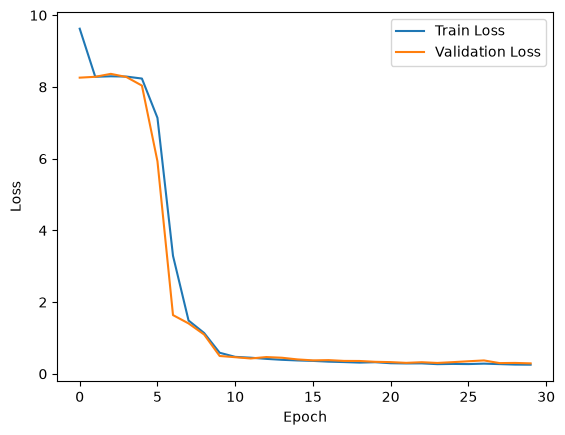

In [10]:
train_losses, valid_losses = train(model, train_dataloader, valid_dataloader, epochs=30)
torch.save(model.state_dict(), 'models/rnn.pth')
plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [11]:
# Test the model on the test set
model.eval()
with torch.no_grad():
    test_loss = 0
    loss_fn = torch.nn.MSELoss()
    for X_batch, y_batch in test_dataloader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        outputs = model(X_batch)  # Use only the first 11 columns as input
        loss = loss_fn(outputs, y_batch)  # The last 10 columns represent the target ranking
        test_loss += loss.item()
print(f"Test Loss: {test_loss / len(test_dataloader):.4f}")

Test Loss: 0.2831


In [25]:
# Let's see the model's predictions on some test data
model.eval()
i = random.randint(0, len(test_dataloader.dataset) - 1)
sample_input = test_dataloader.dataset[i][0].cpu().squeeze()

with torch.no_grad():
    predicted_ranking = model(sample_input.unsqueeze(0).unsqueeze(-1).to(DEVICE)).squeeze(0).cpu().numpy()

y_true = test_dataloader.dataset[i][1].cpu().numpy()  # The last 10 columns represent the target ranking

print(f"Input:                             {sample_input}")
print(f"Predicted Ranking:                 {predicted_ranking}")
print(f"True Ranking:                      {y_true}")
print(f"Predicted (argsorted):             {np.argsort(np.argsort(predicted_ranking))}")
print(f"True order:                        {sample_input[np.argsort(y_true)]}")
print(f"Input sorted by predicted ranking: {sample_input[np.argsort(predicted_ranking)]}")
print(f"Accuracy:                          {np.mean(np.argsort(predicted_ranking) == np.argsort(y_true)) * 100:.2f}%")

Input:                             tensor([825., 434., 844., 988., 520., 965., 509., 599., 261., 976.])
Predicted Ranking:                 [4.9793763  0.76160616 5.449399   8.21698    3.4724505  7.7810926
 2.2814076  3.9405     0.42554817 7.7364545 ]
True Ranking:                      [5. 1. 6. 9. 3. 7. 2. 4. 0. 8.]
Predicted (argsorted):             [5 1 6 9 3 8 2 4 0 7]
True order:                        tensor([261., 434., 509., 520., 599., 825., 844., 965., 976., 988.])
Input sorted by predicted ranking: tensor([261., 434., 509., 520., 599., 825., 844., 976., 965., 988.])
Accuracy:                          80.00%


Average accuracy on test set: 76.9250%


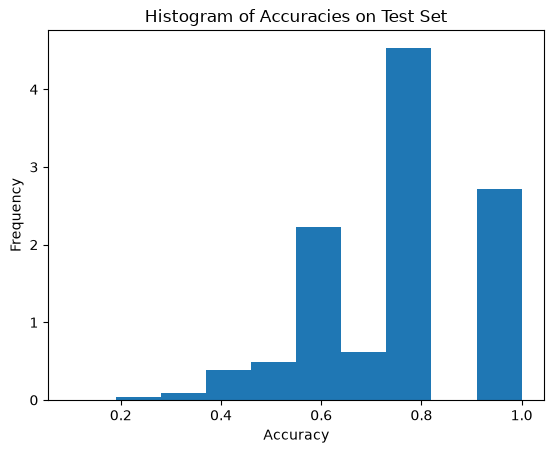

In [28]:
accuracies = []
for X_batch, y_batch in test_dataloader:
    predictions = torch.argsort(torch.argsort(model(X_batch.to(DEVICE)).cpu(), dim=1), dim=1)
    y_batch = y_batch.cpu()  # The last 10 columns represent the target ranking
    accuracies.extend((predictions == y_batch).float().mean(dim=1).tolist())

# Plot histogram of accuracies:
print(f"Average accuracy on test set: {sum(accuracies) / len(accuracies) * 100:.4f}%")
plt.hist(accuracies, bins=10, density=True)
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.title('Histogram of Accuracies on Test Set')
plt.show()

In [12]:
print(f"Percent of arrays it correctly ranked: {sum([1 for acc in accuracies if acc == 1]) / len(accuracies) * 100:.2f}%")

Percent of arrays it correctly ranked: 0.00%


In [32]:
# Let's see the model's predictions on some test data
sample_input = torch.tensor([23, 25, 12, 5, 17, 9, 30, 1, 8, 15], dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    predicted_ranking = model(sample_input.unsqueeze(0).unsqueeze(-1).to(DEVICE)).squeeze(0).cpu().numpy()

y_true = torch.argsort(torch.argsort(sample_input)).cpu().numpy()  # The true ranking of the input array

print(f"Input:                             {sample_input}")
print(f"Predicted Ranking:                 {predicted_ranking}")
print(f"True Ranking:                      {y_true}")
print(f"Predicted (argsorted):             {np.argsort(np.argsort(predicted_ranking))}")
print(f"True order:                        {sample_input[np.argsort(y_true)]}")
print(f"Input sorted by predicted ranking: {sample_input[np.argsort(predicted_ranking)]}")
print(f"Accuracy:                          {np.mean(np.argsort(np.argsort(predicted_ranking)) == y_true):.4f}")

Input:                             tensor([23., 25., 12.,  5., 17.,  9., 30.,  1.,  8., 15.], device='cuda:0')
Predicted Ranking:                 [7.2097435  8.233309   5.902      3.893769   6.340267   2.7319257
 6.6695085  0.69263446 1.93156    1.3332665 ]
True Ranking:                      [7 8 4 1 6 3 9 0 2 5]
Predicted (argsorted):             [8 9 5 4 6 3 7 0 2 1]
True order:                        tensor([ 1.,  5.,  8.,  9., 12., 15., 17., 23., 25., 30.], device='cuda:0')
Input sorted by predicted ranking: tensor([ 1., 15.,  8.,  9.,  5., 12., 17., 30., 23., 25.], device='cuda:0')
Accuracy:                          0.4000
